# Hypergraph Neural Networks for Random Hypergraph Model Classification

A small experiment using **PyTorch Geometric** [1]. We generate hypergraphs from four random hypergraph models, namely, a uniform Erdős–Rényi
hypergraph (ER), a hypergraph preferential-attachment model (HPA), a hypergraph stochastic block model (HSBM), and a random geometric hypergraph (HGEO), and train a hypergraph neural network (HGNN) (a hypergraph convolutional network (HypergraphConv), to be specific [2, 3]) to identify the generating model. Hypergraphs have only 20–40 nodes and roughly 30–60 hyperedges.

Every model draws its hyperedge sizes from the same distribution and produces the same number of hyperedges for a given number of
nodes. So the models are indistinguishable from their size statistics alone.

In [1]:
import random
from itertools import combinations

import numpy as np
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import HypergraphConv, GCNConv, global_mean_pool, global_max_pool

SEED = 8674
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Model_names = ["ER", "HPA", "HSBM", "HGEO"]
Labels = {name: i for i, name in enumerate(Model_names)}

print("PyTorch:", torch.__version__)

PyTorch: 2.10.0+cpu


## Random Hypergraph Models

A hypergraph $H = (V, E)$ has a node set $V$ and a set of *hyperedges* $E \subseteq 2^V$, each of which may contain any number of nodes. We represent a
hypergraph simply as a list of tuples of node indices.

The four generators differ only in how the members of each hyperedge are chosen: ER (a uniformly random $k$-subset of $V$); HPA (nodes drawn sequentially with probability proportional to current degree (rich get richer)); HSBM (with probability $0.85$, all $k$ nodes come from one of two blocks; otherwise uniform); HSBM (nodes are points in $[0,1]^2$; the $k$ nodes nearest a random location form the hyperedge).

The number of hyperedges is $m = \lceil 1.5\,n \rceil$ for every model, and the sizes $k$ are always drawn from the same distribution on $\{2,3,4,5\}$.

In [2]:
SIZE_VALUES = [2, 3, 4, 5]
SIZE_PROBS = [0.35, 0.35, 0.20, 0.10]
RHO = 1.5   #hyperedges per node

def sample_sizes(rng, m):
    """Hyperedge sizes: identical distribution for every model.
    """
    return list(rng.choice(SIZE_VALUES, size = m, p = SIZE_PROBS))

def gen_ER(rng, n, sizes):
    return [tuple(sorted(rng.choice(n, size=k, replace=False))) for k in sizes]

def gen_HPA(rng, n, sizes):
    deg = np.ones(n)  #start at 1 so every node is reachable
    edges = []

    for k in sizes:
        chosen = []
        available = np.ones(n, dtype=bool)

        for _ in range(k):
            p = deg * available
            p = p / p.sum()
            v = rng.choice(n, p=p)
            chosen.append(v)
            available[v] = False

        for v in chosen:
            deg[v] += 1

        edges.append(tuple(sorted(chosen)))
    return edges


def gen_HSBM(rng, n, sizes, n_blocks = 2, p_in = 0.85):
    block = rng.integers(0, n_blocks, size = n)
    members = [np.where(block == b)[0] for b in range(n_blocks)]
    edges = []

    for k in sizes:
        if rng.random() < p_in:
            pool = members[rng.integers(0, n_blocks)]
            if len(pool) >= k:
                edges.append(tuple(sorted(rng.choice(pool, size=k, replace=False))))
                continue
        edges.append(tuple(sorted(rng.choice(n, size=k, replace=False))))

    return edges


def gen_HGEO(rng, n, sizes):
    points = rng.random((n, 2))
    edges = []

    for k in sizes:
        centre = rng.random(2)
        dist = np.linalg.norm(points - centre, axis=1)
        edges.append(tuple(sorted(np.argsort(dist)[:k])))

    return edges

GENERATORS = {"ER": gen_ER, "HPA": gen_HPA, "HSBM": gen_HSBM, "HGEO": gen_HGEO,}

def generate_hypergraph(model, n, rng):
    m = max(2, int(round(RHO * n)))
    sizes = sample_sizes(rng, m)
    edges = GENERATORS[model](rng, n, sizes)
    return [tuple(int(v) for v in e) for e in edges]

In [3]:
rng = np.random.default_rng(SEED)
example = generate_hypergraph("HSBM", 20, rng)

print("Hyperedges:", len(example))
print("First five:", example[:5])

Hyperedges: 30
First five: [(11, 19), (11, 19), (9, 12, 14, 15, 17), (1, 2, 10, 18), (0, 18, 19)]


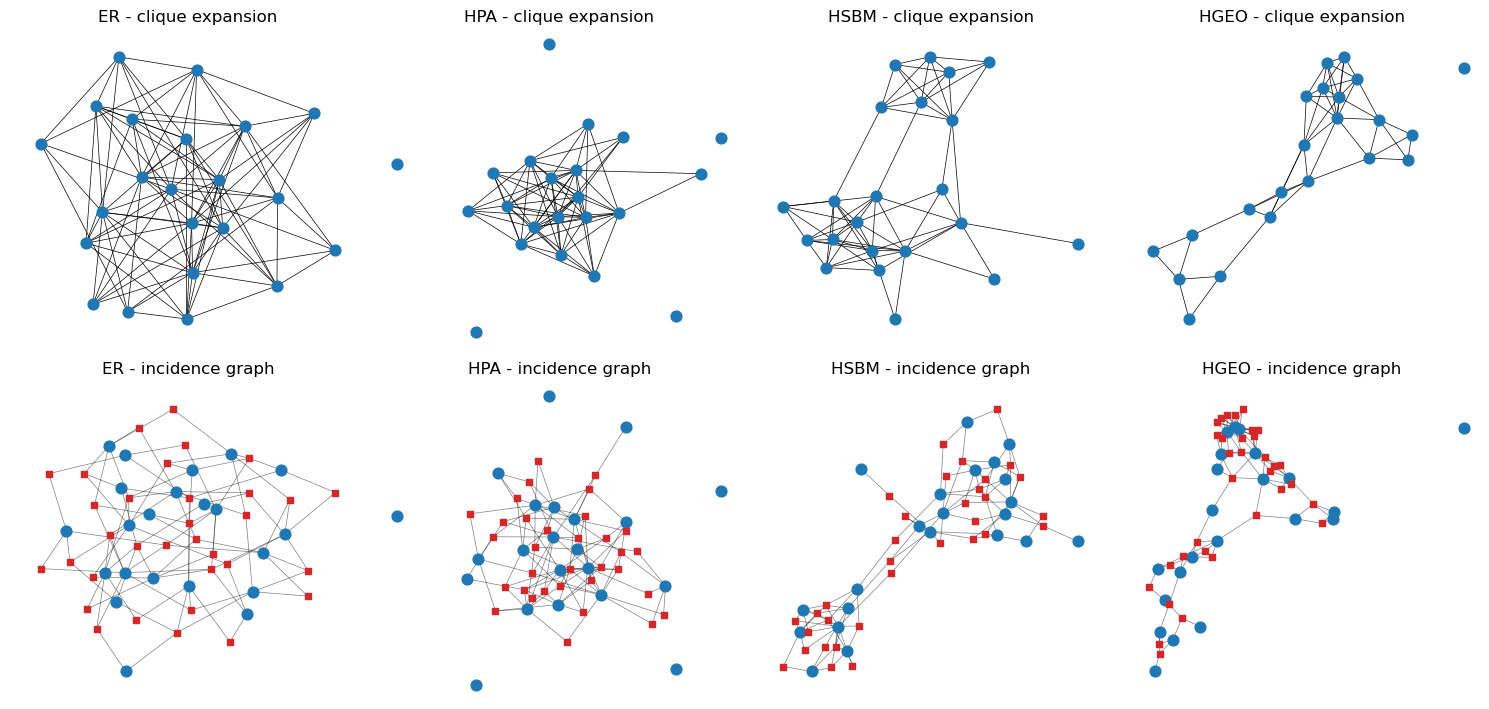

In [4]:
##Visualizing hypergraphs - here, we show two standard views: the clique expansion (top) and the 
#incidence bipartite graph (bottom), where blue circles are nodes and small red squares are hyperedges.

def layout(G):
    core = [v for v in G if G.degree(v) > 0]
    isolated = [v for v in G if G.degree(v) == 0]

    pos = nx.spring_layout(G.subgraph(core), seed = SEED)

    if isolated:
        P = np.array(list(pos.values()))
        centre = P.mean(axis=0)
        radius = np.abs(P - centre).max() * 1.25
        for t, v in enumerate(isolated):
            angle = 2 * np.pi * t / len(isolated) + 0.4
            pos[v] = centre + radius * np.array([np.cos(angle), np.sin(angle)])

    return pos


rng = np.random.default_rng(7)
fig, axes = plt.subplots(2, 4, figsize=(15, 7.2))

for col, name in enumerate(Model_names):
    n = 22
    edges = generate_hypergraph(name, n, rng)

    #Top: clique expansion
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for e in edges:
        G.add_edges_from(combinations(e, 2))

    ax = axes[0, col]
    nx.draw_networkx(G, layout(G), ax = ax, node_size=60, with_labels = False, width = 0.5, node_color = "#1f77b4",)
    ax.set_title(f"{name} - clique expansion")
    ax.axis("off")

    #Bottom: incidence bipartite graph
    B = nx.Graph()
    B.add_nodes_from(range(n))
    for j, e in enumerate(edges):
        B.add_node(("e", j))
        for v in e:
            B.add_edge(v, ("e", j))

    pos = layout(B)
    ax = axes[1, col]
    nx.draw_networkx_edges(B, pos, ax=ax, width=0.5, alpha=0.5)
    nx.draw_networkx_nodes(B, pos, nodelist=list(range(n)), ax=ax, node_size=60, node_color="#1f77b4")
    nx.draw_networkx_nodes(B, pos, nodelist=[("e", j) for j in range(len(edges))], ax=ax,
                           node_size=22, node_shape = "s", node_color = "#d62728",)
    ax.set_title(f"{name} - incidence graph")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Encoding a Hypergraph for PyTorch Geometric

PyG represents a hypergraph by its incidence structure: `hyperedge_index` is a $2 \times \lvert I \rvert$ matrix whose columns are (node, hyperedge) incidences. `HypergraphConv` then performs two-stage message passing, nodes -> hyperedges -> nodes.

In [5]:
class HyperData(Data):
    
    def __inc__(self, key, value, *args, **kwargs):
        if key == "hyperedge_index":
            # row 0 indexes nodes, row 1 indexes hyperedges
            return torch.tensor([[self.num_nodes], [self.num_hyperedges]])
        return super().__inc__(key, value, *args, **kwargs)

    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == "hyperedge_index":
            return 1
        return super().__cat_dim__(key, value, *args, **kwargs)


def node_features(n, edges):
    degree = np.zeros(n)
    size_sum = np.zeros(n)
    size_max = np.zeros(n)
    neighbours = [set() for _ in range(n)]

    for e in edges:
        k = len(e)
        for v in e:
            degree[v] += 1
            size_sum[v] += k
            size_max[v] = max(size_max[v], k)
            neighbours[v].update(u for u in e if u != v)

    mean_size = np.where(degree > 0, size_sum / np.maximum(degree, 1), 0.0)
    distinct = np.array([len(s) for s in neighbours], dtype=float)

    #1.0 means every incident hyperedge brings fresh neighbours.
    #Smaller values mean the incident hyperedges overlap.
    redundancy = distinct / np.maximum(size_sum - degree, 1.0)

    return np.stack([degree, mean_size, size_max, distinct, redundancy], axis=1)


def to_pyg(n, edges, label):
    rows, cols = [], []
    for j, e in enumerate(edges):
        for v in e:
            rows.append(int(v))
            cols.append(j)

    hyperedge_index = torch.tensor([rows, cols], dtype = torch.long)

    #Clique expansion.
    pairs = set()
    for e in edges:
        pairs.update(combinations(sorted(int(v) for v in e), 2))

    if pairs:
        edge_index = torch.tensor(sorted(pairs), dtype = torch.long).t()
        edge_index = torch.cat([edge_index, edge_index.flip(0)], dim = 1)
    else:
        edge_index = torch.empty(2, 0, dtype = torch.long)

    data = HyperData(
        x = torch.tensor(node_features(n, edges), dtype = torch.float),
        hyperedge_index = hyperedge_index,
        edge_index = edge_index,
        y = torch.tensor([label]),)
    data.num_nodes = n
    data.num_hyperedges = len(edges)
    return data

## Building the Dataset

Here, we generate 150 hypergraphs per model (600 in total), each with 20–40 nodes.

In [6]:
def make_dataset(per_model = 150, n_min = 20, n_max = 40, seed = SEED):
    rng = np.random.default_rng(seed)
    dataset, raw = [], []

    for name in Model_names:
        for _ in range(per_model):
            n = int(rng.integers(n_min, n_max + 1))
            edges = generate_hypergraph(name, n, rng)
            dataset.append(to_pyg(n, edges, Labels[name]))
            raw.append((n, edges))

    order = np.random.permutation(len(dataset))
    dataset = [dataset[i] for i in order]
    raw = [raw[i] for i in order]
    return dataset, raw


dataset, raw_hypergraphs = make_dataset()
labels = np.array([int(d.y.item()) for d in dataset])

print("Total hypergraphs:", len(dataset))
print("First hypergraph:", dataset[0])
print("Nodes:", dataset[0].num_nodes)
print("Hyperedges:", dataset[0].num_hyperedges)
print("Incidences:", dataset[0].hyperedge_index.size(1))

for name, count in zip(Model_names, np.bincount(labels, minlength = 4)):
    print(f"{name}: {count}")

Total hypergraphs: 600
First hypergraph: HyperData(x=[35, 5], edge_index=[2, 246], y=[1], hyperedge_index=[2, 161], num_nodes=35, num_hyperedges=52)
Nodes: 35
Hyperedges: 52
Incidences: 161
ER: 150
HPA: 150
HSBM: 150
HGEO: 150


## Splitting and Standardizing

The split is at the hypergraph level, that is, each hypergraph is one independent example. Node features live on very different scales (degree runs to ~15, the redundancy ratio is bounded by 1).

In [7]:
indices = np.arange(len(dataset))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state = SEED, stratify = labels)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state = SEED, stratify = labels[temp_idx])

#Standardization statistics from the training split only.
x_train = torch.cat([dataset[i].x for i in train_idx], dim = 0)
mu = x_train.mean(dim = 0)
sigma = x_train.std(dim = 0).clamp(min = 1e-6)

for data in dataset:
    data.x = (data.x - mu) / sigma

train_dataset = [dataset[i] for i in train_idx]
val_dataset = [dataset[i] for i in val_idx]
test_dataset = [dataset[i] for i in test_idx]

print("Feature means:", np.round(mu.numpy(), 2))
print("Feature stds: ", np.round(sigma.numpy(), 2))
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Feature means: [4.56 3.19 4.14 7.31 0.72]
Feature stds:  [2.86 0.9  1.21 4.02 0.26]
Train: 420
Validation: 90
Test: 90


## Defining the Hypergraph Neural Network (HGNN)

Architecture: **node features -> linear encoder -> HypergraphConv -> HypergraphConv -> (mean ‖ max) pooling -> MLP -> model class**

Each `HypergraphConv` layer sends messages from nodes to the hyperedges containing them and back again, so a node's representation after two layers reflects the hyperedges it belongs to and the hyperedges its co-members belong to. We concatenate mean and max pooling: the mean captures typical local structure, and the max captures whether an extreme node exists anywhere, which is exactly the signature of preferential attachment.

In [8]:
class HGNN(nn.Module):
    def __init__(self, in_channels = 5, hidden_channels = 48, num_classes = 4):
        super().__init__()

        self.encoder = nn.Linear(in_channels, hidden_channels)
        self.conv1 = HypergraphConv(hidden_channels, hidden_channels)
        self.conv2 = HypergraphConv(hidden_channels, hidden_channels)

        self.fc1 = nn.Linear(2 * hidden_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, num_classes)

    def forward(self, batch):
        num_edges = int(batch.num_hyperedges.sum())

        x = F.relu(self.encoder(batch.x))

        x = F.relu(self.conv1(x, batch.hyperedge_index, num_edges = num_edges))
        x = F.dropout(x, p=0.20, training=self.training)

        x = F.relu(self.conv2(x, batch.hyperedge_index, num_edges = num_edges))

        #Variable-size hypergraph -> fixed-size representation.
        x = torch.cat(
            [global_mean_pool(x, batch.batch), global_max_pool(x, batch.batch)],
            dim = 1,)

        x = F.relu(self.fc1(x))
        return self.fc2(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(HGNN())

Device: cpu
HGNN(
  (encoder): Linear(in_features=5, out_features=48, bias=True)
  (conv1): HypergraphConv(48, 48)
  (conv2): HypergraphConv(48, 48)
  (fc1): Linear(in_features=96, out_features=48, bias=True)
  (fc2): Linear(in_features=48, out_features=4, bias=True)
)


In [9]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

criterion = nn.CrossEntropyLoss()


def run_epoch(model, optimizer, loader, training = False):
    model.train(training)

    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)

        if training:
            optimizer.zero_grad()

        logits = model(batch)
        loss = criterion(logits, batch.y.view(-1))

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        correct += (logits.argmax(dim=1) == batch.y.view(-1)).sum().item()
        total += batch.num_graphs

    return total_loss / total, correct / total


def train(model, epochs=40, lr=0.01, verbose=True):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay = 5e-4)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, optimizer, train_loader, training = True)

        with torch.no_grad():
            val_loss, val_acc = run_epoch(model, optimizer, val_loader, training = False)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(
                f"Epoch {epoch:02d} | "
                f"train loss={train_loss:.3f} | train acc={train_acc:.3f} | "
                f"val loss={val_loss:.3f} | val acc={val_acc:.3f}"
            )

    model.load_state_dict(best_state)
    return model, history, best_val_acc

## Training

We use 40 epochs, and the best validation model is retained.

In [10]:
torch.manual_seed(SEED)

hgnn = HGNN()
hgnn, history, best_val = train(hgnn, epochs = 40)

print(f"\nBest validation accuracy: {best_val:.3f}")

Epoch 01 | train loss=0.892 | train acc=0.664 | val loss=0.440 | val acc=0.811
Epoch 05 | train loss=0.271 | train acc=0.888 | val loss=0.206 | val acc=0.900
Epoch 10 | train loss=0.198 | train acc=0.917 | val loss=0.151 | val acc=0.911
Epoch 15 | train loss=0.129 | train acc=0.948 | val loss=0.137 | val acc=0.944
Epoch 20 | train loss=0.119 | train acc=0.950 | val loss=0.087 | val acc=0.956
Epoch 25 | train loss=0.120 | train acc=0.950 | val loss=0.098 | val acc=0.944
Epoch 30 | train loss=0.215 | train acc=0.933 | val loss=0.107 | val acc=0.967
Epoch 35 | train loss=0.107 | train acc=0.952 | val loss=0.153 | val acc=0.922
Epoch 40 | train loss=0.082 | train acc=0.964 | val loss=0.128 | val acc=0.956

Best validation accuracy: 0.978


Epoch 15 | train loss=0.114 | train acc=0.957 | val loss=0.140 | val acc=0.967


Epoch 20 | train loss=0.137 | train acc=0.940 | val loss=0.181 | val acc=0.944


Epoch 25 | train loss=0.110 | train acc=0.957 | val loss=0.239 | val acc=0.922


Epoch 30 | train loss=0.086 | train acc=0.967 | val loss=0.097 | val acc=0.967


Epoch 35 | train loss=0.092 | train acc=0.964 | val loss=0.171 | val acc=0.933


Epoch 40 | train loss=0.066 | train acc=0.974 | val loss=0.259 | val acc=0.922

Best validation accuracy: 0.967


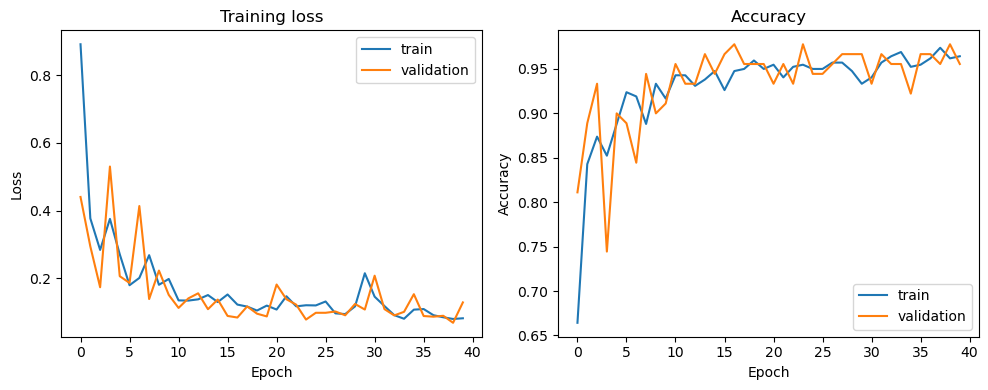

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluating on Unseen Hypergraphs

              precision    recall  f1-score   support

          ER      0.885     1.000     0.939        23
         HPA      1.000     1.000     1.000        22
        HSBM      1.000     0.818     0.900        22
        HGEO      0.958     1.000     0.979        23

    accuracy                          0.956        90
   macro avg      0.961     0.955     0.954        90
weighted avg      0.960     0.956     0.954        90



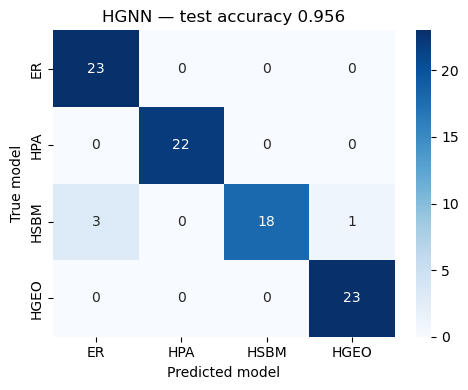

In [12]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    y_true, y_pred = [], []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        y_true.extend(batch.y.view(-1).cpu().numpy())
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())

    return np.array(y_true), np.array(y_pred)


y_true, y_pred = predict(hgnn, test_loader)
hgnn_acc = (y_true == y_pred).mean()

print(classification_report(y_true, y_pred, target_names = Model_names, digits = 3))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels = Model_names, yticklabels = Model_names, cmap = "Blues",)

plt.xlabel("Predicted model")
plt.ylabel("True model")
plt.title(f"HGNN — test accuracy {hgnn_acc:.3f}")
plt.tight_layout()
plt.show()

## References

[1] PyTorch Geometric (PyG) - https://pytorch-geometric.readthedocs.io/en/latest<br>
[2] HypergraphConv - https://pytorch-geometric.readthedocs.io/en/2.5.0/generated/torch_geometric.nn.conv.HypergraphConv.html<br>
[3] Feng, Y., You, H., Zhang, Z., Ji, R., & Gao, Y. (2019). *Hypergraph Convolution and Hypergraph Attention*. arXiv:1901.08150<br>